In [1]:
%cd ../scripts/
import sys
import os
sys.path.append("../")
sys.path.append("../Modules")
import analysis

import os
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

/home/drfrbc/Neural-Modeling/scripts


In [2]:
sims_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-03-26-11-59-tuning_tuft_syn_densities_while_decreasing"

In [3]:
save_folder = os.path.join(sims_dir, "Soma FR Results")
voltages_save_folder = os.path.join(save_folder, 'soma voltages')
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

if not os.path.exists(voltages_save_folder):
    os.makedirs(voltages_save_folder)

--No graphics will be displayed.


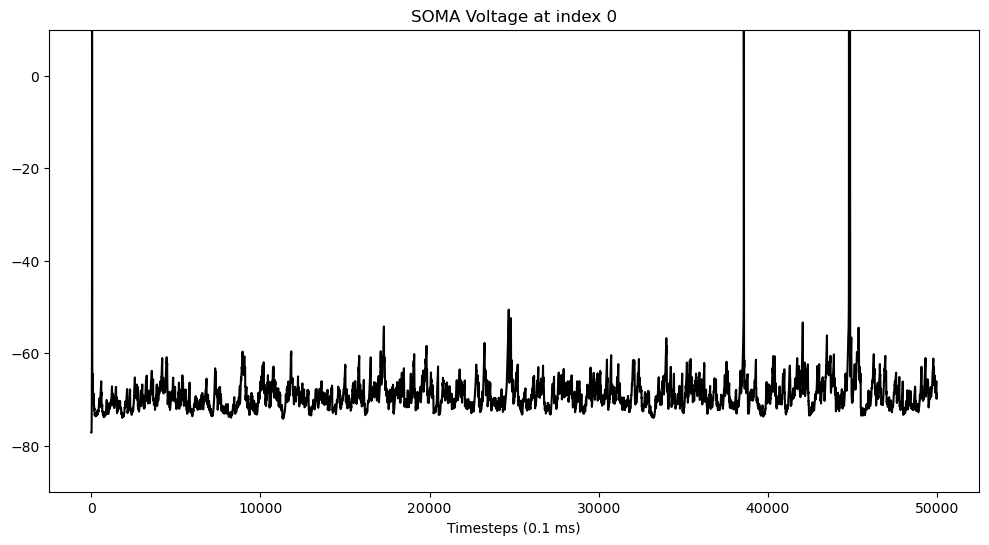

7865134 Soma firing rate 0.8


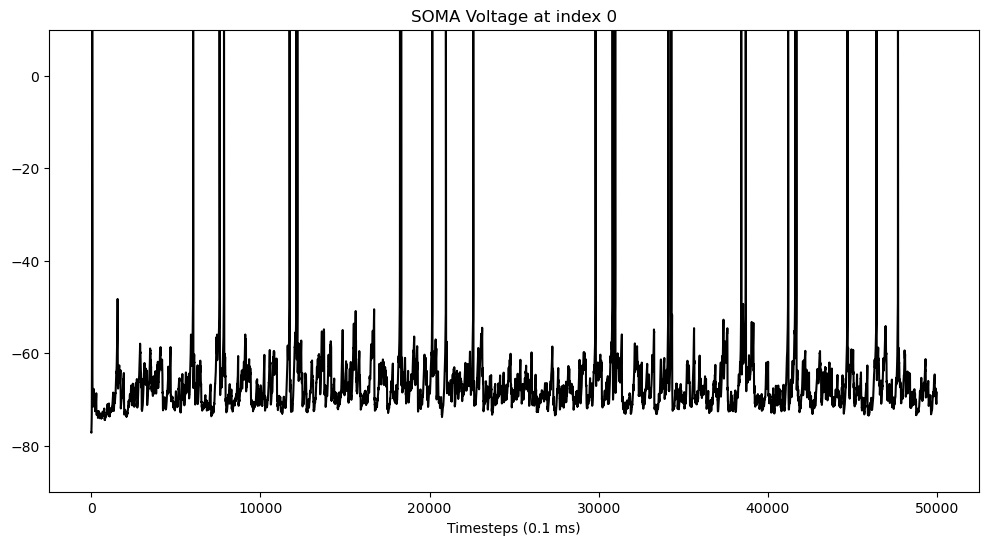

99835 Soma firing rate 5.0


In [ ]:
sims_data = []
for i,sim_name in enumerate(os.listdir(sims_dir)):
    sim_dir = os.path.join(sims_dir, sim_name) # get individual sim path
    if sim_dir == voltages_save_folder or sim_dir == save_folder:
        continue
    # load spike times, calculate mean,std FR
    # plot voltage

    # load parameters
    parameters = analysis.DataReader.load_parameters(sim_dir)

    # # load recorded data
    # sim_data = {
    #     # 'v': analysis.DataReader.read_data(sim_dir, "v").T,
    #     # 'hva': analysis.DataReader.read_data(sim_dir, "ica_Ca_HVA").T,
    #     # 'lva': analysis.DataReader.read_data(sim_dir, "ica_Ca_LVAst").T,
    #     # 'ih': analysis.DataReader.read_data(sim_dir, "ihcn_Ih").T,
    #     # 'nmda': analysis.DataReader.read_data(sim_dir, "i_NMDA").T,
    #     # 'na': analysis.DataReader.read_data(sim_dir, "gNaTa_t_NaTa_t").T,
    #     'spktimes': analysis.DataReader.read_data(sim_dir, "soma_spikes")[0][:],
    #     'spkinds': np.sort((analysis.DataReader.read_data(sim_dir, "soma_spikes")[0][:] * 10).astype(int)),
    #     # 'na_df': pd.read_csv(os.path.join(sim_dir, 'na.csv')),
    #     # 'ca_df': pd.read_csv(os.path.join(sim_dir, 'ca.csv')),
    #     # 'nmda_df': pd.read_csv(os.path.join(sim_dir, 'nmda.csv'))
    # }
    # sims_data[i]=sim_data # store spktimes from each simulation

    v = analysis.DataReader.read_data(sim_dir, "v").T

    # plot soma voltage
    time_points=np.arange(0,int(parameters.h_tstop/parameters.h_dt))
    time_points = time_points[0:49999]
    # time_points = time_points[100000:149999]
    # time_points = time_points[450000:499999]
    colors = ['r*', 'g*', 'b*', 'm*', 'y*', 'k*']
    plt.figure(figsize=(12, 6))

    plt.plot(v[time_points, 0], colors[-1].split('*')[0])
    plt.ylim([-90, 10])
    plt.title(f'SOMA Voltage at index {0}')
    plt.xlabel(f'Timesteps ({parameters.h_dt} ms)')

    plt.savefig(os.path.join(voltages_save_folder, f"{parameters.numpy_random_state}"))
    plt.show()

    # Count the number of spikes in the soma
    # Function to count the first occurrence of True in consecutive trues
    def count_first_true(arr):
        return np.sum((arr > -10) & np.concatenate(([True], arr[:-1] <= -10)))
    soma_spike_count = count_first_true(v[:, 0])
    # print(f"Soma spike count {soma_spike_count}")
    sim_duration = len(v[:, 0])
    # print(f"Simulation duration in timesteps: {sim_duration}")
    sim_duration_in_sec = sim_duration / ((1/parameters.h_dt) * 1000)
    # print(f"Simulation duration in seconds: {sim_duration_in_sec}")
    soma_spike_rate = soma_spike_count / (len(v[:, 0]) / 10000)
    # print(f"Soma firing rate {round(soma_spike_rate, 3)}")
    print(f"{parameters.numpy_random_state} Soma firing rate {round(soma_spike_rate, 3)}")
    sims_data.append(soma_spike_rate)

In [ ]:
print(f"across {len(os.listdir(sims_dir))} seeds...")
print(f"\n Soma FR mean: {np.mean(sims_data):.3}\n Soma FR std: {np.std(sims_data):.3}")

In [ ]:
# visualize the distribution of soma firing rates:
plt.hist(sims_data)
plt.title(f"mean: {np.mean(sims_data):.3}  std: {np.std(sims_data):.3}")
plt.xlabel('Soma Firing Rate')
plt.ylabel("# simulations")
plt.savefig(os.path.join(save_folder, 'soma FR distribution'))

In [ ]:
import pickle
all_parameters = [analysis.DataReader.load_parameters(os.path.join(sims_dir, sim_dir)) for sim_dir in os.listdir(sims_dir) if os.path.join(sims_dir, sim_dir) not in [save_folder, voltages_save_folder]]

with open(os.path.join(save_folder, "parameters_all_seeds.pickle"), "wb") as file:
    pickle.dump(all_parameters, file)